In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: mps


## 1. Selección y Análisis del Departamento

In [2]:

df_full = pd.read_csv('../data/processed/dataset_anual_encoded.csv')

print(f"Dataset completo: {df_full.shape}")
print(f"\nDepartamentos únicos: {df_full['departamento_id'].nunique()}")

# Ver top departamentos
dept_counts = df_full['departamento_id'].value_counts()
print(f"\nTop 10 departamentos con más registros:")
print(dept_counts.head(10))

Dataset completo: (104607, 38)

Departamentos únicos: 474

Top 10 departamentos con más registros:
departamento_id
SANTA FE - GENERAL LOPEZ            525
CORDOBA - UNION                     523
BUENOS AIRES - CORONEL SUAREZ       523
BUENOS AIRES - GENERAL LA MADRID    515
BUENOS AIRES - TRENQUE LAUQUEN      511
BUENOS AIRES - RIVADAVIA            511
BUENOS AIRES - PEHUAJO              510
BUENOS AIRES - CARLOS TEJEDOR       503
LA PAMPA - ATREUCO                  497
CORDOBA - GENERAL SAN MARTIN        495
Name: count, dtype: int64


In [3]:
DEPARTAMENTO_SELECCIONADO = 'SANTA FE - GENERAL LOPEZ'

df_dept = df_full[df_full['departamento_id'] == DEPARTAMENTO_SELECCIONADO].copy()

print(f"Departamento seleccionado: {DEPARTAMENTO_SELECCIONADO}")
print(f"Total de registros: {len(df_dept)}")
print(f"Rango de años: {df_dept['año'].min()} - {df_dept['año'].max()}")
print(f"Total de años: {df_dept['año'].nunique()}")
print(f"Cultivos únicos: {df_dept['cultivo'].nunique()}")
print(f"\nDistribución por cultivo:")
print(df_dept['cultivo'].value_counts())

Departamento seleccionado: SANTA FE - GENERAL LOPEZ
Total de registros: 525
Rango de años: 1970 - 2025
Total de años: 56
Cultivos únicos: 20

Distribución por cultivo:
cultivo
Maíz                56
Girasol             56
Sorgo               55
Avena               50
Cebada cervecera    41
Soja 2da            25
Soja 1ra            25
Centeno             25
Alpiste             23
Maní                21
Lino                21
Cebada forrajera    21
Colza               20
Mijo                20
Mandarina           18
Limón               16
Naranja             16
Pomelo               7
Ajo                  5
Arveja               4
Name: count, dtype: int64


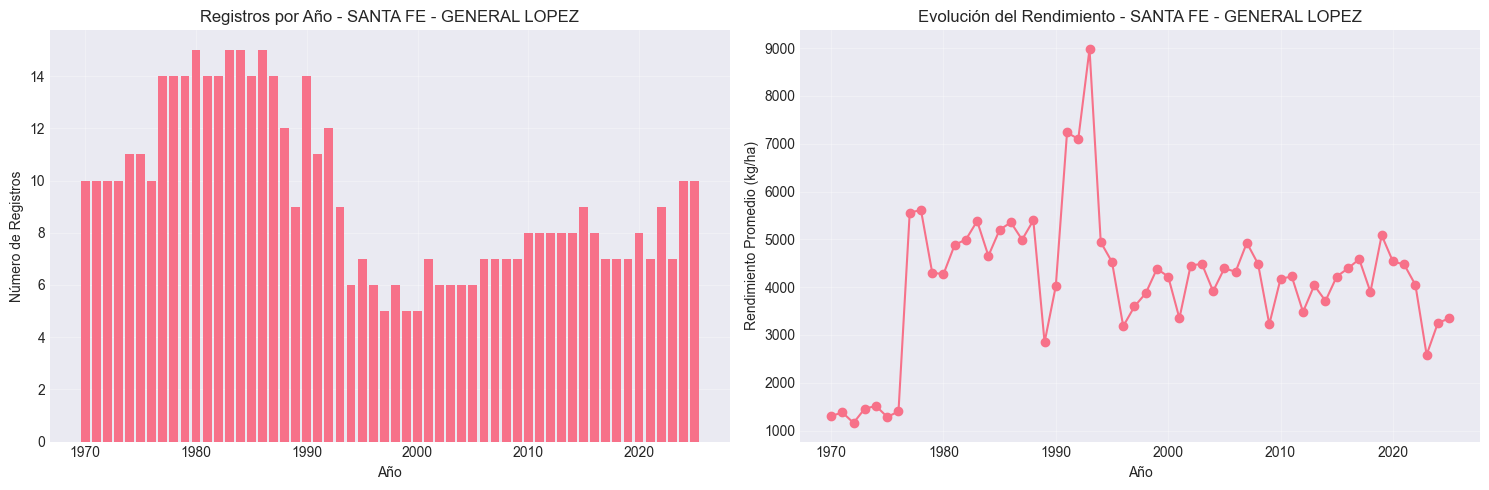

In [4]:
# Visualización temporal
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Registros por año
registros_por_año = df_dept['año'].value_counts().sort_index()
axes[0].bar(registros_por_año.index, registros_por_año.values)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de Registros')
axes[0].set_title(f'Registros por Año - {DEPARTAMENTO_SELECCIONADO}')
axes[0].grid(True, alpha=0.3)

# Rendimiento promedio por año
rendimiento_por_año = df_dept.groupby('año')['rendimiento'].mean()
axes[1].plot(rendimiento_por_año.index, rendimiento_por_año.values, marker='o')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Rendimiento Promedio (kg/ha)')
axes[1].set_title(f'Evolución del Rendimiento - {DEPARTAMENTO_SELECCIONADO}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/dept_especifico_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Feature Engineering para Departamento Específico

In [5]:
def create_engineered_features(df):
    """
    Crea nuevas features mediante feature engineering.
    (Misma función que en notebook 05)
    """
    df_eng = df.copy()
    
    temp_cols = [f'temperatura_mes_{i}' for i in range(1, 13)]
    precip_cols = [f'precipitacion_mes_{i}' for i in range(1, 13)]
    
    # Estadísticas anuales
    df_eng['temp_media_anual'] = df[temp_cols].mean(axis=1)
    df_eng['temp_std_anual'] = df[temp_cols].std(axis=1)
    df_eng['temp_min_anual'] = df[temp_cols].min(axis=1)
    df_eng['temp_max_anual'] = df[temp_cols].max(axis=1)
    df_eng['temp_rango_anual'] = df_eng['temp_max_anual'] - df_eng['temp_min_anual']
    
    df_eng['precip_total_anual'] = df[precip_cols].sum(axis=1)
    df_eng['precip_media_anual'] = df[precip_cols].mean(axis=1)
    df_eng['precip_std_anual'] = df[precip_cols].std(axis=1)
    df_eng['precip_min_anual'] = df[precip_cols].min(axis=1)
    df_eng['precip_max_anual'] = df[precip_cols].max(axis=1)
    
    # Features estacionales
    verano_meses = [12, 1, 2]
    otoño_meses = [3, 4, 5]
    invierno_meses = [6, 7, 8]
    primavera_meses = [9, 10, 11]
    
    df_eng['temp_verano'] = df[[f'temperatura_mes_{m}' for m in verano_meses]].mean(axis=1)
    df_eng['temp_otoño'] = df[[f'temperatura_mes_{m}' for m in otoño_meses]].mean(axis=1)
    df_eng['temp_invierno'] = df[[f'temperatura_mes_{m}' for m in invierno_meses]].mean(axis=1)
    df_eng['temp_primavera'] = df[[f'temperatura_mes_{m}' for m in primavera_meses]].mean(axis=1)
    
    df_eng['precip_verano'] = df[[f'precipitacion_mes_{m}' for m in verano_meses]].sum(axis=1)
    df_eng['precip_otoño'] = df[[f'precipitacion_mes_{m}' for m in otoño_meses]].sum(axis=1)
    df_eng['precip_invierno'] = df[[f'precipitacion_mes_{m}' for m in invierno_meses]].sum(axis=1)
    df_eng['precip_primavera'] = df[[f'precipitacion_mes_{m}' for m in primavera_meses]].sum(axis=1)
    
    # Interacciones
    df_eng['temp_precip_ratio'] = df_eng['temp_media_anual'] / (df_eng['precip_media_anual'] + 1)
    df_eng['temp_x_precip'] = df_eng['temp_media_anual'] * df_eng['precip_media_anual']
    
    # Variabilidad
    df_eng['coef_var_temp'] = df_eng['temp_std_anual'] / (df_eng['temp_media_anual'] + 1)
    df_eng['coef_var_precip'] = df_eng['precip_std_anual'] / (df_eng['precip_media_anual'] + 1)
    
    # Suelo
    df_eng['suelo_calidad_score'] = (df_eng['suelo_ind_prod'] * df_eng['suelo_porc_sue1'] * 
                                      df_eng['suelo_profund_s1']) / 10000
    
    # Producción
    df_eng['produccion_por_hectarea'] = df_eng['produccion_total'] / (df_eng['sup_sembrada_total'] + 1)
    
    # Diferencias estacionales
    df_eng['temp_diff_verano_invierno'] = df_eng['temp_verano'] - df_eng['temp_invierno']
    df_eng['precip_diff_verano_invierno'] = df_eng['precip_verano'] - df_eng['precip_invierno']
    
    return df_eng

try:
    df_dept_eng = create_engineered_features(df_dept)
    print(f"Features con engineering: {df_dept_eng.shape}")
except Exception as e:
    import traceback
    print("Error al crear engineered features:", e)
    traceback.print_exc()
    raise

Features con engineering: (525, 64)


## 3. Split Temporal y Preparación de Datos

In [6]:
import os
fe_path = '../data/processed/feature_cols_eng.pkl'
base_path = '../data/processed/feature_cols.pkl'
if os.path.exists(fe_path):
    with open(fe_path, 'rb') as f:
        feature_cols_eng = pickle.load(f)
    print(f'Loaded feature_cols_eng from {fe_path} (len={len(feature_cols_eng)})')
else:
    # Fallback: reconstruir a partir de feature_cols + nuevas features de este departamento (menos robusto)
    with open(base_path, 'rb') as f:
        feature_cols = pickle.load(f)
    new_features = [col for col in df_dept_eng.columns if col not in df_dept.columns]
    feature_cols_eng = feature_cols + new_features
    print('Warning: feature_cols_eng.pkl not found; reconstructed feature_cols_eng from local df_dept (may differ from training).')

# También cargamos feature_cols originales si existe (útil para contar nuevas features)
if os.path.exists(base_path):
    with open(base_path, 'rb') as f:
        feature_cols = pickle.load(f)
else:
    feature_cols = [f for f in feature_cols_eng if 'temperatura_mes' in f or 'precipitacion_mes' in f][:31]

# Calcular cuales son las engineered features relativas al dataset del departamento
new_features = [f for f in feature_cols_eng if f not in feature_cols]

print(f"Features originales: {len(feature_cols)}")
print(f"Features engineered: {len(new_features)}")
print(f"Total features (feature_cols_eng): {len(feature_cols_eng)}")

Loaded feature_cols_eng from ../data/processed/feature_cols_eng.pkl (len=56)
Features originales: 31
Features engineered: 25
Total features (feature_cols_eng): 56


In [7]:
# Split temporal (80/20)
df_sorted = df_dept_eng.sort_values('año').reset_index(drop=True)

años_unicos = sorted(df_sorted['año'].unique())
n_años = len(años_unicos)
split_año_idx = int(n_años * 0.8)
año_split = años_unicos[split_año_idx]

print(f"Total de años: {n_años}")
print(f"Año de split (80/20): {año_split}")
print(f"Train: años {años_unicos[0]} a {años_unicos[split_año_idx-1]}")
print(f"Test: años {años_unicos[split_año_idx]} a {años_unicos[-1]}")

train_mask = df_sorted['año'] < año_split
test_mask = df_sorted['año'] >= año_split

df_train_dept = df_sorted[train_mask].copy()
df_test_dept = df_sorted[test_mask].copy()

# Features originales
X_train_dept = df_train_dept[feature_cols].values
y_train_dept = df_train_dept['rendimiento'].values
X_test_dept = df_test_dept[feature_cols].values
y_test_dept = df_test_dept['rendimiento'].values

# Features engineered
X_train_dept_eng = df_train_dept[feature_cols_eng].values
X_test_dept_eng = df_test_dept[feature_cols_eng].values

print(f"\nTamaño del conjunto de entrenamiento: {X_train_dept.shape} ({len(df_train_dept)/len(df_sorted)*100:.1f}%)")
print(f"Tamaño del conjunto de test: {X_test_dept.shape} ({len(df_test_dept)/len(df_sorted)*100:.1f}%)")
print(f"\nDistribución temporal:")
print(f"  Train: {df_train_dept['año'].min()}-{df_train_dept['año'].max()}")
print(f"  Test: {df_test_dept['año'].min()}-{df_test_dept['año'].max()}")

Total de años: 56
Año de split (80/20): 2014
Train: años 1970 a 2013
Test: años 2014 a 2025

Tamaño del conjunto de entrenamiento: (428, 31) (81.5%)
Tamaño del conjunto de test: (97, 31) (18.5%)

Distribución temporal:
  Train: 1970-2013
  Test: 2014-2025


In [8]:
# Normalización
scaler_dept = StandardScaler()
X_train_dept_scaled = scaler_dept.fit_transform(X_train_dept)
X_test_dept_scaled = scaler_dept.transform(X_test_dept)

scaler_dept_eng = StandardScaler()
X_train_dept_eng_scaled = scaler_dept_eng.fit_transform(X_train_dept_eng)
X_test_dept_eng_scaled = scaler_dept_eng.transform(X_test_dept_eng)

print("Datos normalizados.")

Datos normalizados.


## 4. Funciones de Evaluación

In [9]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Resultados para: {model_name}")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

## 5. Entrenamiento de Modelos Específicos del Departamento

### 5.1 Regresión Lineal

In [10]:
print("Entrenando Regresión Lineal (X) - Departamento Específico...")

lr_x_dept = LinearRegression()
lr_x_dept.fit(X_train_dept_scaled, y_train_dept)

y_pred_lr_x_dept = lr_x_dept.predict(X_test_dept_scaled)
results_lr_x_dept = evaluate_model(y_test_dept, y_pred_lr_x_dept, "LR (X) - Dept Específico")

Entrenando Regresión Lineal (X) - Departamento Específico...

Resultados para: LR (X) - Dept Específico
RMSE: 2702.9895
MAE:  2093.0978
R2:   -0.2749


In [11]:
print("Entrenando Regresión Lineal (X+FE) - Departamento Específico...")

lr_x_eng_dept = LinearRegression()
lr_x_eng_dept.fit(X_train_dept_eng_scaled, y_train_dept)

y_pred_lr_x_eng_dept = lr_x_eng_dept.predict(X_test_dept_eng_scaled)
results_lr_x_eng_dept = evaluate_model(y_test_dept, y_pred_lr_x_eng_dept, "LR (X+FE) - Dept Específico")

Entrenando Regresión Lineal (X+FE) - Departamento Específico...

Resultados para: LR (X+FE) - Dept Específico
RMSE: 2881.7909
MAE:  2169.6838
R2:   -0.4492


### 5.2 XGBoost

In [12]:
print("Entrenando XGBoost (X) - Departamento Específico...")

xgb_x_dept = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_x_dept.fit(X_train_dept, y_train_dept)

y_pred_xgb_x_dept = xgb_x_dept.predict(X_test_dept)
results_xgb_x_dept = evaluate_model(y_test_dept, y_pred_xgb_x_dept, "XGB (X) - Dept Específico")

Entrenando XGBoost (X) - Departamento Específico...

Resultados para: XGB (X) - Dept Específico
RMSE: 1512.0307
MAE:  1131.3971
R2:   0.6010


In [13]:
print("Entrenando XGBoost (X+FE) - Departamento Específico...")

xgb_x_eng_dept = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_x_eng_dept.fit(X_train_dept_eng, y_train_dept)

y_pred_xgb_x_eng_dept = xgb_x_eng_dept.predict(X_test_dept_eng)
results_xgb_x_eng_dept = evaluate_model(y_test_dept, y_pred_xgb_x_eng_dept, "XGB (X+FE) - Dept Específico")

Entrenando XGBoost (X+FE) - Departamento Específico...

Resultados para: XGB (X+FE) - Dept Específico
RMSE: 1522.6465
MAE:  1117.2731
R2:   0.5954


### 5.3 Red Neuronal

In [14]:
class NeuralNetRegressor(nn.Module):
    def __init__(self, input_size, hidden_sizes, dropout_rate=0.3):
        super(NeuralNetRegressor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_nn(X_train, y_train, X_test, y_test, input_size, num_epochs=100):
    # Preparar datos
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # Modelo
    model = NeuralNetRegressor(input_size, hidden_sizes=[128, 64], dropout_rate=0.2)
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    
    # Entrenamiento
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
    
    # Predicción
    model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        predictions = model(X_test_tensor).cpu().numpy().flatten()
    
    return predictions

In [15]:
print("Entrenando Red Neuronal (X+FE) - Departamento Específico...\n")

y_pred_nn_dept = train_nn(
    X_train_dept_eng_scaled, 
    y_train_dept, 
    X_test_dept_eng_scaled, 
    y_test_dept,
    input_size=X_train_dept_eng_scaled.shape[1],
    num_epochs=100
)

results_nn_dept = evaluate_model(y_test_dept, y_pred_nn_dept, "NN (X+FE) - Dept Específico")

Entrenando Red Neuronal (X+FE) - Departamento Específico...

Epoch [20/100], Loss: 47276204.0000
Epoch [40/100], Loss: 39636152.0000
Epoch [60/100], Loss: 79937512.0000
Epoch [80/100], Loss: 75923904.0000
Epoch [100/100], Loss: 57369872.0000

Resultados para: NN (X+FE) - Dept Específico
RMSE: 4350.1043
MAE:  3769.9237
R2:   -2.3022


## 6. Evaluación de Modelos Generales en el Departamento Específico

In [16]:
# Cargar modelos generales entrenados
with open('../models/lr_x_eng.pkl', 'rb') as f:
    lr_general = pickle.load(f)

with open('../models/xgb_x_eng.pkl', 'rb') as f:
    xgb_general = pickle.load(f)

print("Modelos generales cargados.")

Modelos generales cargados.


In [17]:
# Filtrar datos de test del departamento del dataset completo
# Necesitamos los datos del modelo general para este departamento

# Cargar datos del modelo general
df_full_eng = create_engineered_features(df_full)

# Filtrar por departamento y por años de test
df_test_general = df_full_eng[
    (df_full_eng['departamento_id'] == DEPARTAMENTO_SELECCIONADO) &
    (df_full_eng['año'] >= año_split)
].copy()

# Asegurarnos de que todas las columnas esperadas estén presentes en df_test_general
missing_feats = [f for f in feature_cols_eng if f not in df_test_general.columns]
if len(missing_feats) > 0:
    print(f'Atención: {len(missing_feats)} features ausentes en df_test_general. Se rellenarán con ceros:')
    for f in missing_feats:
        print(' -', f)
    for f in missing_feats:
        df_test_general[f] = 0.0

# Ahora podemos construir X_test_general con el orden de feature_cols_eng
X_test_general = df_test_general[feature_cols_eng].values
y_test_general = df_test_general['rendimiento'].values

# Cargar scaler del modelo general
with open('../data/processed/scaler_eng.pkl', 'rb') as f:
    scaler_general = pickle.load(f)

X_test_general_scaled = scaler_general.transform(X_test_general)

print(f"Datos de test para modelo general: {X_test_general.shape}")

Datos de test para modelo general: (97, 56)


In [18]:
# Predicciones del modelo general
y_pred_lr_general = lr_general.predict(X_test_general_scaled)
results_lr_general = evaluate_model(y_test_general, y_pred_lr_general, "LR (X+FE) - Modelo GENERAL")

y_pred_xgb_general = xgb_general.predict(X_test_general)
results_xgb_general = evaluate_model(y_test_general, y_pred_xgb_general, "XGB (X+FE) - Modelo GENERAL")


Resultados para: LR (X+FE) - Modelo GENERAL
RMSE: 12793.8599
MAE:  6055.5743
R2:   -27.5632

Resultados para: XGB (X+FE) - Modelo GENERAL
RMSE: 1356.2129
MAE:  843.4950
R2:   0.6790


## 7. Comparación: Modelo General vs Modelo Específico

In [19]:
# Compilar todos los resultados
comparison_df = pd.DataFrame([
    results_lr_x_dept,
    results_lr_x_eng_dept,
    results_xgb_x_dept,
    results_xgb_x_eng_dept,
    results_nn_dept,
    results_lr_general,
    results_xgb_general
])

print("\n" + "="*80)
print(f"COMPARACIÓN: MODELOS ESPECÍFICOS vs GENERALES")
print(f"Departamento: {DEPARTAMENTO_SELECCIONADO}")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


COMPARACIÓN: MODELOS ESPECÍFICOS vs GENERALES
Departamento: SANTA FE - GENERAL LOPEZ
                       model         rmse         mae         r2
    LR (X) - Dept Específico  2702.989454 2093.097794  -0.274946
 LR (X+FE) - Dept Específico  2881.790884 2169.683794  -0.449199
   XGB (X) - Dept Específico  1512.030678 1131.397098   0.601045
XGB (X+FE) - Dept Específico  1522.646507 1117.273078   0.595423
 NN (X+FE) - Dept Específico  4350.104307 3769.923736  -2.302192
  LR (X+FE) - Modelo GENERAL 12793.859902 6055.574324 -27.563154
 XGB (X+FE) - Modelo GENERAL  1356.212874  843.494989   0.679034


In [20]:
# Análisis de mejora
print("\nANÁLISIS DE MEJORA (Específico vs General):\n")

# LR
lr_mejora_r2 = results_lr_x_eng_dept['r2'] - results_lr_general['r2']
lr_mejora_rmse = results_lr_general['rmse'] - results_lr_x_eng_dept['rmse']
print(f"Regresión Lineal (X+FE):")
print(f"  R² Específico: {results_lr_x_eng_dept['r2']:.4f}")
print(f"  R² General: {results_lr_general['r2']:.4f}")
print(f"  Mejora R²: {lr_mejora_r2:+.4f}")
print(f"  Mejora RMSE: {lr_mejora_rmse:+.4f}\n")

# XGBoost
xgb_mejora_r2 = results_xgb_x_eng_dept['r2'] - results_xgb_general['r2']
xgb_mejora_rmse = results_xgb_general['rmse'] - results_xgb_x_eng_dept['rmse']
print(f"XGBoost (X+FE):")
print(f"  R² Específico: {results_xgb_x_eng_dept['r2']:.4f}")
print(f"  R² General: {results_xgb_general['r2']:.4f}")
print(f"  Mejora R²: {xgb_mejora_r2:+.4f}")
print(f"  Mejora RMSE: {xgb_mejora_rmse:+.4f}")


ANÁLISIS DE MEJORA (Específico vs General):

Regresión Lineal (X+FE):
  R² Específico: -0.4492
  R² General: -27.5632
  Mejora R²: +27.1140
  Mejora RMSE: +9912.0690

XGBoost (X+FE):
  R² Específico: 0.5954
  R² General: 0.6790
  Mejora R²: -0.0836
  Mejora RMSE: -166.4336


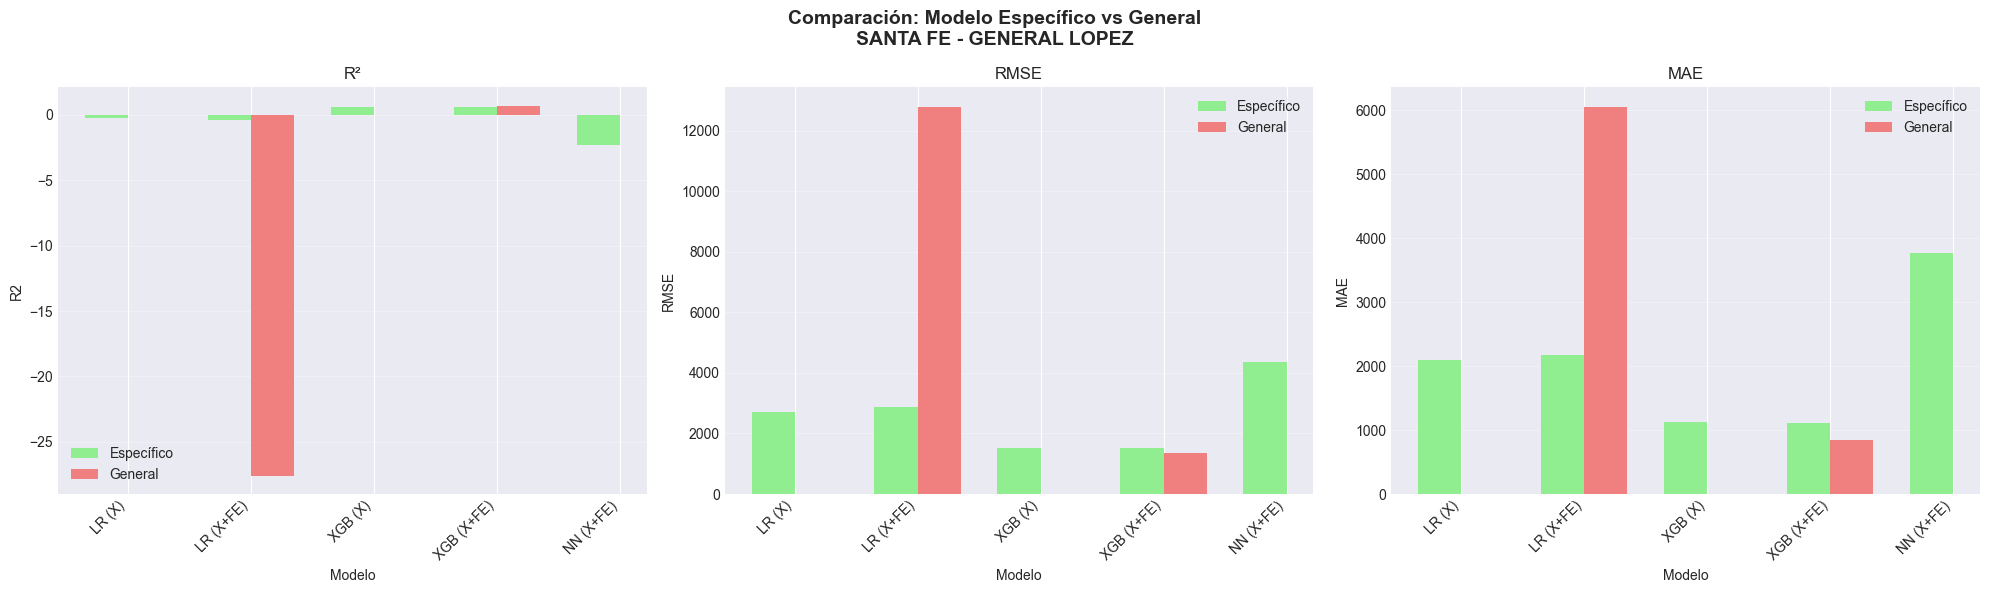

In [26]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['r2', 'rmse', 'mae']
titles = ['R²', 'RMSE', 'MAE']

# Separar modelos específicos y generales
models_especificos = comparison_df[~comparison_df['model'].str.contains('GENERAL')]
models_generales = comparison_df[comparison_df['model'].str.contains('GENERAL')]

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    values_esp = models_especificos[metric].values
    values_gen = models_generales[metric].values
    
    x = np.arange(len(models_especificos))
    width = 0.35
    
    axes[idx].bar(x - width/2, values_esp, width, label='Específico', color='lightgreen')
    
    # Solo mostrar generales para los últimos 2 (LR y XGB con FE)
    gen_positions = [len(models_especificos) - 4, len(models_especificos) - 2]
    axes[idx].bar(np.array(gen_positions) + width/2, values_gen, width, 
                  label='General', color='lightcoral')
    
    axes[idx].set_xlabel('Modelo')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(title)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([m.replace(' - Dept Específico', '') for m in models_especificos['model']], 
                              rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Comparación: Modelo Específico vs General\n{DEPARTAMENTO_SELECCIONADO}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/dept_especifico_vs_general.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Análisis de Predicciones

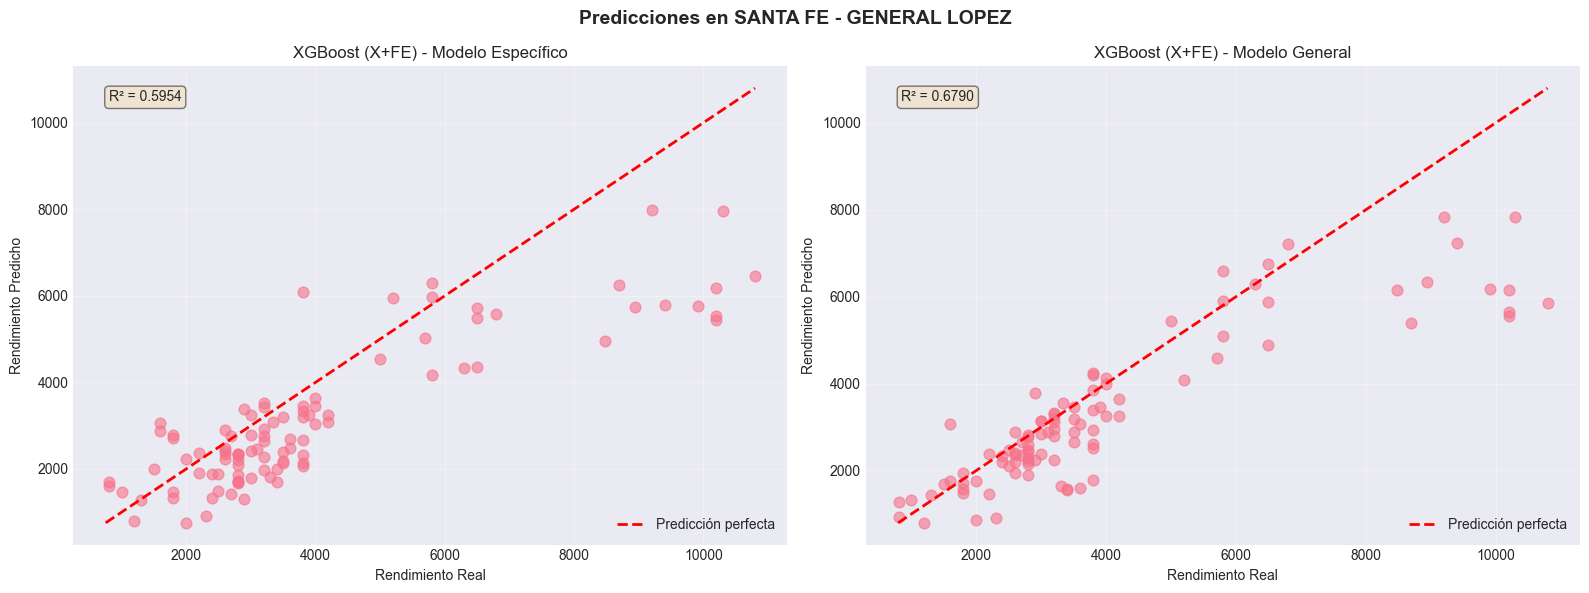

In [22]:
# Comparar predicciones de XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_predictions(y_true, y_pred, title, ax):
    ax.scatter(y_true, y_pred, alpha=0.6, s=60)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
    ax.set_xlabel('Rendimiento Real')
    ax.set_ylabel('Rendimiento Predicho')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    r2 = r2_score(y_true, y_pred)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_predictions(y_test_dept, y_pred_xgb_x_eng_dept, 
                'XGBoost (X+FE) - Modelo Específico', axes[0])
plot_predictions(y_test_general, y_pred_xgb_general, 
                'XGBoost (X+FE) - Modelo General', axes[1])

plt.suptitle(f'Predicciones en {DEPARTAMENTO_SELECCIONADO}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/dept_especifico_predicciones.png', dpi=300, bbox_inches='tight')
plt.show()

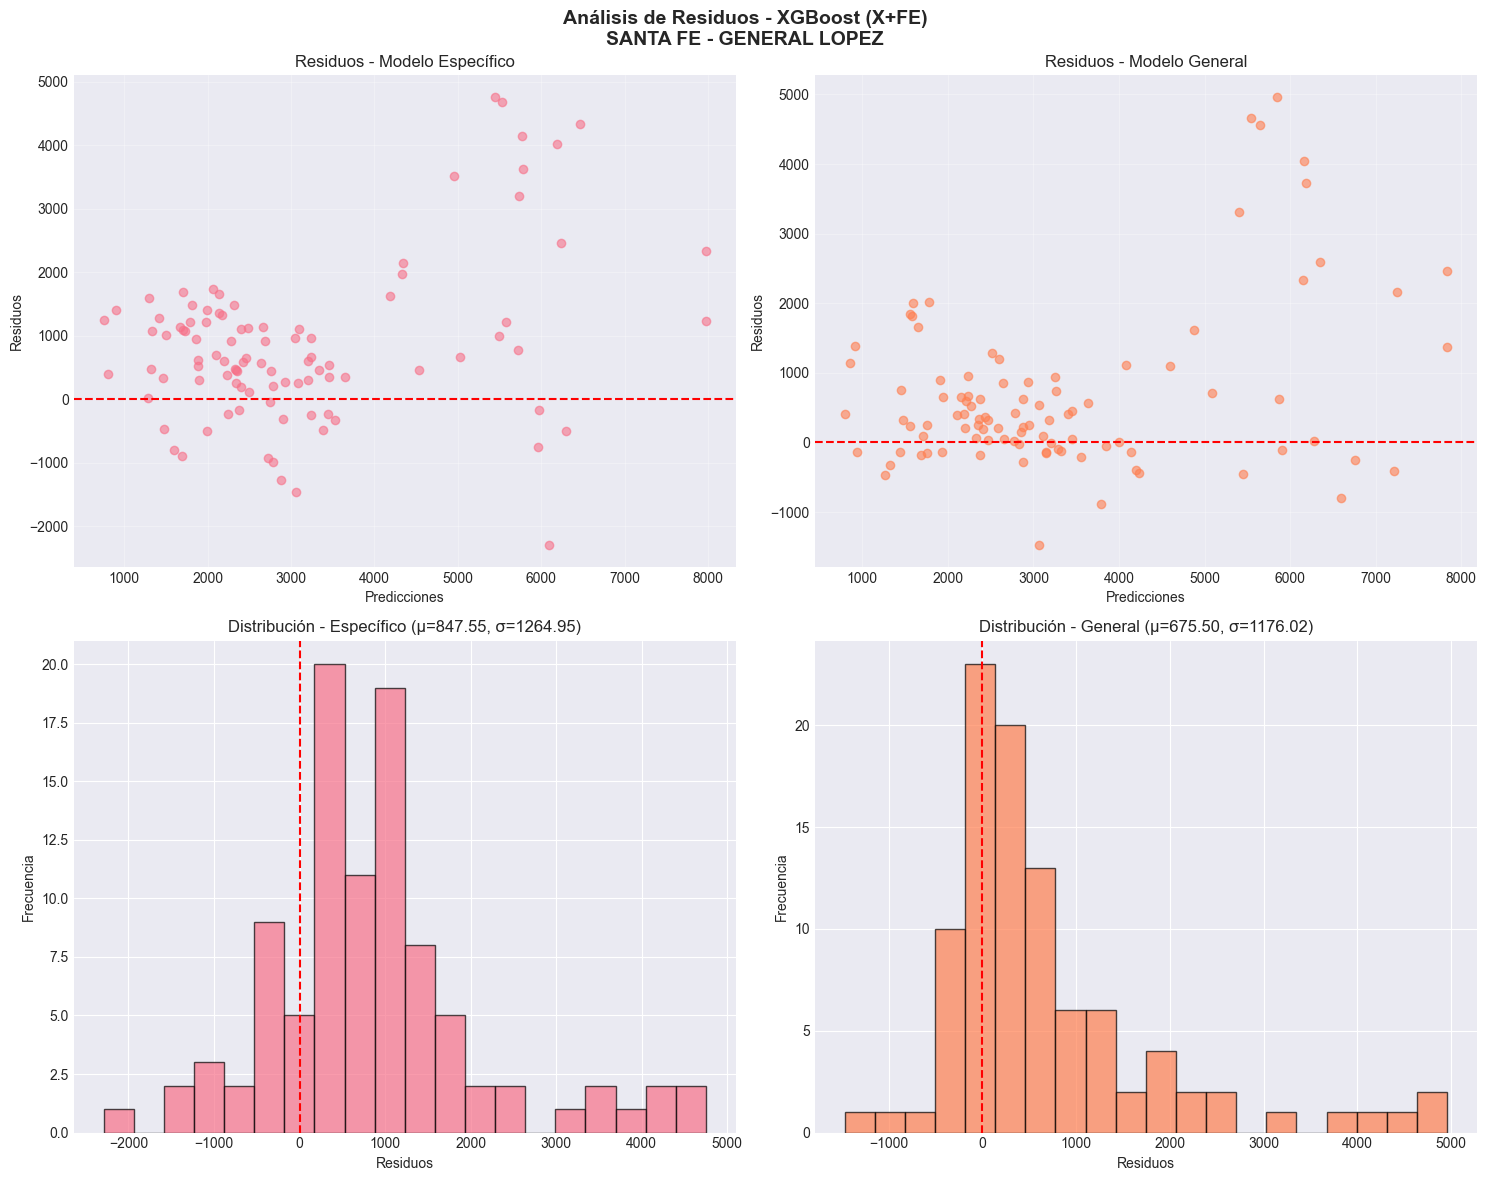

In [23]:
# Análisis de residuos
residuals_esp = y_test_dept - y_pred_xgb_x_eng_dept
residuals_gen = y_test_general - y_pred_xgb_general

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Residuos vs predicciones - Específico
axes[0, 0].scatter(y_pred_xgb_x_eng_dept, residuals_esp, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicciones')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos - Modelo Específico')
axes[0, 0].grid(True, alpha=0.3)

# Residuos vs predicciones - General
axes[0, 1].scatter(y_pred_xgb_general, residuals_gen, alpha=0.6, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicciones')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos - Modelo General')
axes[0, 1].grid(True, alpha=0.3)

# Distribución de residuos - Específico
axes[1, 0].hist(residuals_esp, bins=20, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title(f'Distribución - Específico (μ={residuals_esp.mean():.2f}, σ={residuals_esp.std():.2f})')

# Distribución de residuos - General
axes[1, 1].hist(residuals_gen, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title(f'Distribución - General (μ={residuals_gen.mean():.2f}, σ={residuals_gen.std():.2f})')

plt.suptitle(f'Análisis de Residuos - XGBoost (X+FE)\n{DEPARTAMENTO_SELECCIONADO}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/dept_especifico_residuos.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Feature Importance del Modelo Específico


Top 20 features más importantes - XGBoost Específico de SANTA FE - GENERAL LOPEZ:
                        feature  importance
30           sup_sembrada_total    0.356488
28              cultivo_encoded    0.125330
29             produccion_total    0.087767
11          precipitacion_mes_6    0.054404
39             precip_min_anual    0.046827
55  precip_diff_verano_invierno    0.035349
20           temperatura_mes_11    0.034734
15          precipitacion_mes_8    0.017639
21         precipitacion_mes_11    0.014349
31             temp_media_anual    0.013790
48             precip_primavera    0.012312
32               temp_std_anual    0.011622
46                 precip_otoño    0.011567
44               temp_primavera    0.010777
35             temp_rango_anual    0.009372
54    temp_diff_verano_invierno    0.008539
9           precipitacion_mes_5    0.008059
5           precipitacion_mes_3    0.008047
7           precipitacion_mes_4    0.007000
0             temperatura_mes_1    0.

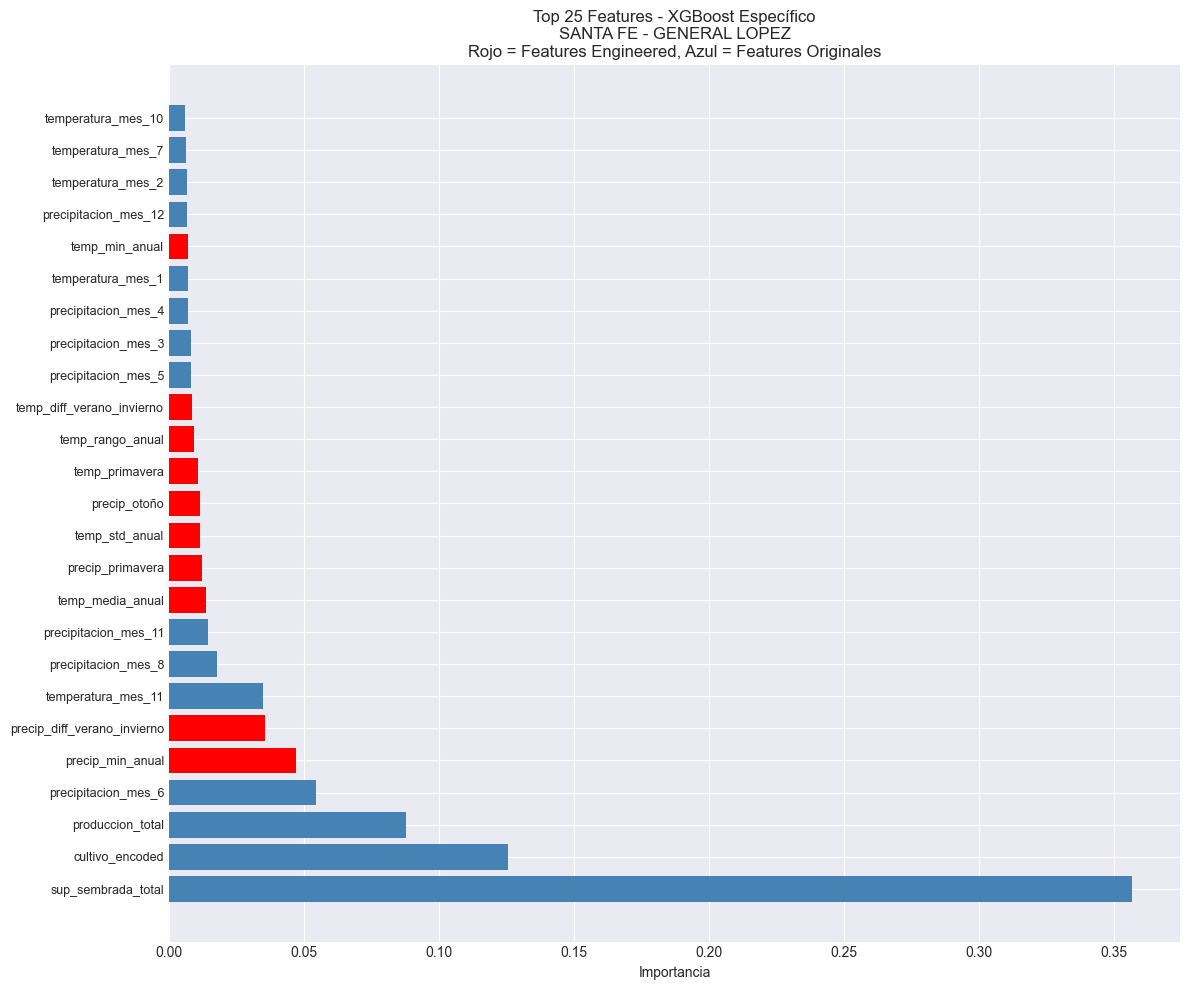

In [24]:
# Feature importance del XGBoost específico
feature_importance_dept = pd.DataFrame({
    'feature': feature_cols_eng,
    'importance': xgb_x_eng_dept.feature_importances_
})
feature_importance_dept = feature_importance_dept.sort_values('importance', ascending=False)

print(f"\nTop 20 features más importantes - XGBoost Específico de {DEPARTAMENTO_SELECCIONADO}:")
print(feature_importance_dept.head(20))

# Visualización
plt.figure(figsize=(12, 10))
top_n = 25
top_features = feature_importance_dept.head(top_n)

colors = ['red' if feat in new_features else 'steelblue' for feat in top_features['feature']]

plt.barh(range(top_n), top_features['importance'].values, color=colors)
plt.yticks(range(top_n), top_features['feature'].values, fontsize=9)
plt.xlabel('Importancia')
plt.title(f'Top {top_n} Features - XGBoost Específico\n{DEPARTAMENTO_SELECCIONADO}\n' + 
          'Rojo = Features Engineered, Azul = Features Originales')
plt.tight_layout()
plt.savefig('../figures/dept_especifico_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Guardar Resultados

In [25]:
# Guardar resultados de la comparación
comparison_df.to_csv('../results/dept_especifico_vs_general.csv', index=False)
print("Resultados guardados en CSV.")

# Guardar modelos específicos
with open(f'../models/xgb_dept_{DEPARTAMENTO_SELECCIONADO.replace(" ", "_")}.pkl', 'wb') as f:
    pickle.dump(xgb_x_eng_dept, f)

print("Modelos específicos guardados.")

Resultados guardados en CSV.
Modelos específicos guardados.
